In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv(r"C:\Users\acer\Desktop\Extended_Employee_Performance_and_Productivity_Data.csv")

In [6]:
df.head()

,Employee_ID,Department,Gender,Age,Job_Title,Hire_Date,Years_At_Company,Education_Level,Performance_Score,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Sick_Days,Remote_Work_Frequency,Team_Size,Training_Hours,Promotions,Employee_Satisfaction_Score,Resigned
0,1,IT,Male,55,Specialist,2022-01-19 08:03:05.556036,2,High School,5,6750.0,33,32,22,2,0,14,66,0,2.63,False
1,2,Finance,Male,29,Developer,2024-04-18 08:03:05.556036,0,High School,5,7500.0,34,34,13,14,100,12,61,2,1.72,False
2,3,Finance,Male,55,Specialist,2015-10-26 08:03:05.556036,8,High School,3,5850.0,37,27,6,3,50,10,1,0,3.17,False
3,4,Customer Support,Female,48,Analyst,2016-10-22 08:03:05.556036,7,Bachelor,2,4800.0,52,10,28,12,100,10,0,1,1.86,False
4,5,Engineering,Female,36,Analyst,2021-07-23 08:03:05.556036,3,Bachelor,2,4800.0,38,11,29,13,100,15,9,1,1.25,False


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Employee_ID                  100000 non-null  int64  
 1   Department                   100000 non-null  object 
 2   Gender                       100000 non-null  object 
 3   Age                          100000 non-null  int64  
 4   Job_Title                    100000 non-null  object 
 5   Hire_Date                    100000 non-null  object 
 6   Years_At_Company             100000 non-null  int64  
 7   Education_Level              100000 non-null  object 
 8   Performance_Score            100000 non-null  int64  
 9   Monthly_Salary               100000 non-null  float64
 10  Work_Hours_Per_Week          100000 non-null  int64  
 11  Projects_Handled             100000 non-null  int64  
 12  Overtime_Hours               100000 non-null  int64  
 13  

In [10]:
df.isnull().sum()

Employee_ID                    0
Department                     0
Gender                         0
Age                            0
Job_Title                      0
Hire_Date                      0
Years_At_Company               0
Education_Level                0
Performance_Score              0
Monthly_Salary                 0
Work_Hours_Per_Week            0
Projects_Handled               0
Overtime_Hours                 0
Sick_Days                      0
Remote_Work_Frequency          0
Team_Size                      0
Training_Hours                 0
Promotions                     0
Employee_Satisfaction_Score    0
Resigned                       0
dtype: int64

In [11]:
df = df.drop_duplicates()

In [12]:
df.describe()

,Employee_ID,Age,Years_At_Company,Performance_Score,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Sick_Days,Remote_Work_Frequency,Team_Size,Training_Hours,Promotions,Employee_Satisfaction_Score
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,41.029410,4.476070,2.995430,6403.211000,44.956950,24.431170,14.514930,7.008550,50.090500,10.013560,49.506060,0.999720,2.999088
std,28867.657797,11.244121,2.869336,1.414726,1372.508717,8.942003,14.469584,8.664026,4.331591,35.351157,5.495405,28.890383,0.815872,1.150719
min,1.000000,22.000000,0.000000,1.000000,3850.000000,30.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000
25%,25000.750000,31.000000,2.000000,2.000000,5250.000000,37.000000,12.000000,7.000000,3.000000,25.000000,5.000000,25.000000,0.000000,2.010000
50%,50000.500000,41.000000,4.000000,3.000000,6500.000000,45.000000,24.000000,15.000000,7.000000,50.000000,10.000000,49.000000,1.000000,3.000000
75%,75000.250000,51.000000,7.000000,4.000000,7500.000000,53.000000,37.000000,22.000000,11.000000,75.000000,15.000000,75.000000,2.000000,3.990000
max,100000.000000,60.000000,10.000000,5.000000,9000.000000,60.000000,49.000000,29.000000,14.000000,100.000000,19.000000,99.000000,2.000000,5.000000


In [13]:
df["Monthly_Salary"].mean()

np.float64(6403.211)

In [14]:
df["Monthly_Salary"].median()

6500.0

In [15]:
df["Monthly_Salary"].std()

1372.5087166506169

In [16]:
df["Monthly_Salary"].quantile([0.25,0.50,0.75])

0.25    5250.0
0.50    6500.0
0.75    7500.0
Name: Monthly_Salary, dtype: float64

In [17]:
df["Monthly_Salary"].quantile(0.90)

np.float64(8400.0)

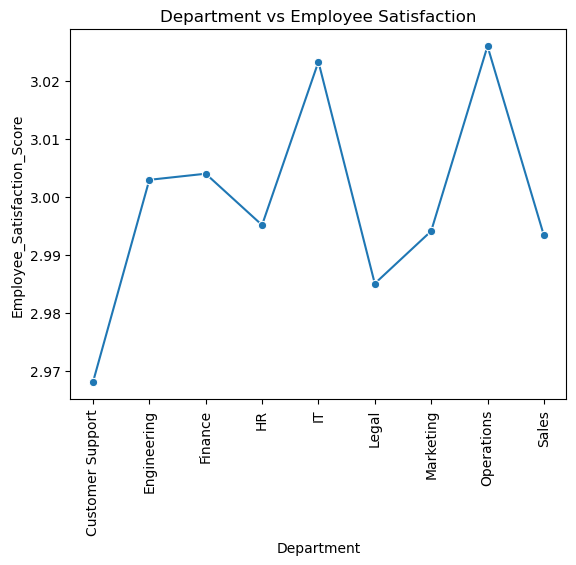

In [18]:
dept_sat = df.groupby(
"Department"
)["Employee_Satisfaction_Score"].mean()

dept_sat = dept_sat.reset_index()

sns.lineplot(
x="Department",
y="Employee_Satisfaction_Score",
data=dept_sat,
marker="o"
)

plt.xticks(rotation=90)

plt.title(
"Department vs Employee Satisfaction"
)

plt.show()

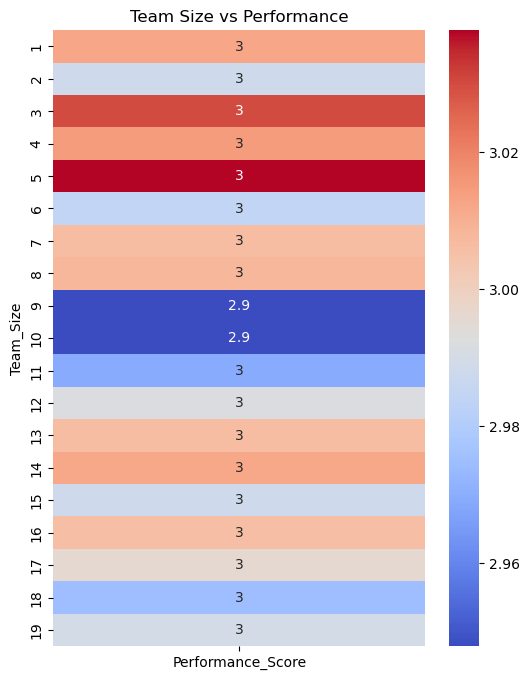

In [19]:
heat = df.pivot_table(
values="Performance_Score",
index="Team_Size",
aggfunc="mean"
)

plt.figure(figsize=(6,8))

sns.heatmap(
heat,
annot=True,
cmap="coolwarm"
)

plt.title(
"Team Size vs Performance"
)

plt.show()

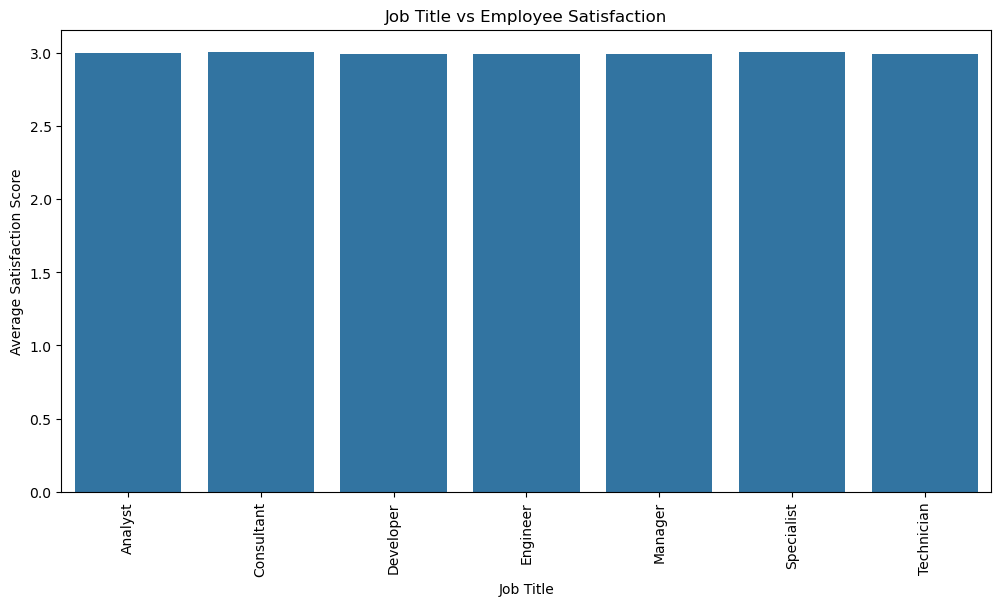

In [20]:
job_sat = df.groupby(
"Job_Title"
)["Employee_Satisfaction_Score"].mean()

job_sat = job_sat.reset_index()

plt.figure(figsize=(12,6))

sns.barplot(
x="Job_Title",
y="Employee_Satisfaction_Score",
data=job_sat
)

plt.xticks(rotation=90)

plt.title(
"Job Title vs Employee Satisfaction"
)

plt.xlabel(
"Job Title"
)

plt.ylabel(
"Average Satisfaction Score"
)

plt.show()

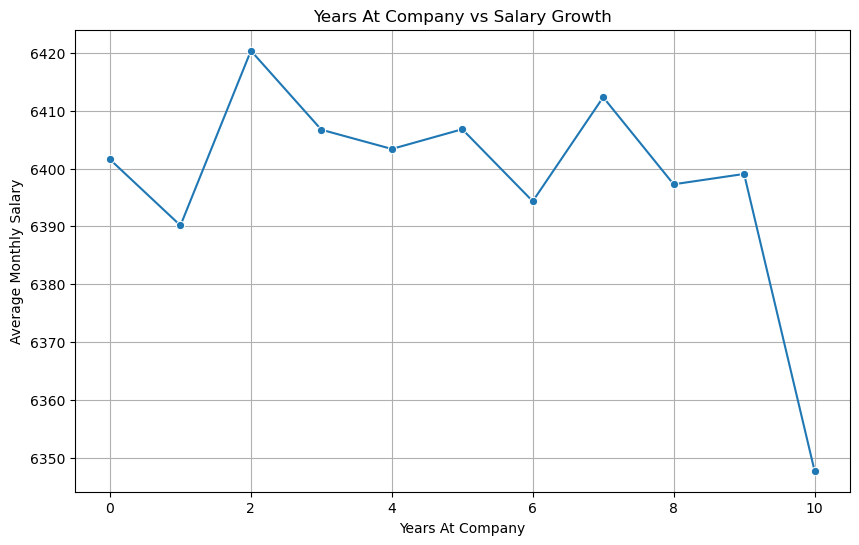

In [21]:
trend = df.groupby(
"Years_At_Company"
)["Monthly_Salary"].mean()

trend = trend.reset_index()

plt.figure(figsize=(10,6))

sns.lineplot(
x="Years_At_Company",
y="Monthly_Salary",
data=trend,
marker="o"
)

plt.title(
"Years At Company vs Salary Growth"
)

plt.xlabel(
"Years At Company"
)

plt.ylabel(
"Average Monthly Salary"
)

plt.grid()

plt.show()

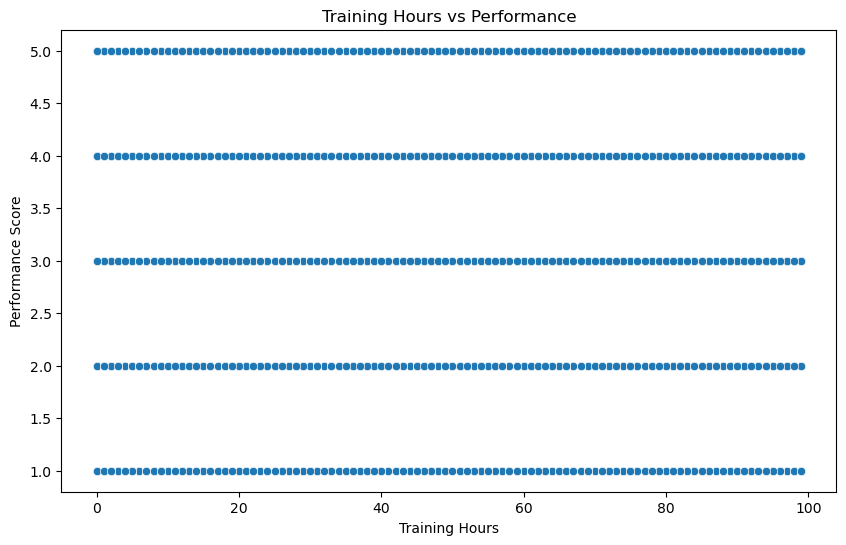

In [22]:
plt.figure(figsize=(10,6))

sns.scatterplot(
x="Training_Hours",
y="Performance_Score",
data=df
)

plt.title(
"Training Hours vs Performance"
)

plt.xlabel(
"Training Hours"
)

plt.ylabel(
"Performance Score"
)

plt.show()

In [24]:
corr1=df[
[
"Training_Hours",
"Performance_Score"
]
].corr()

corr1

,Training_Hours,Performance_Score
Training_Hours,1.000000,0.002358
Performance_Score,0.002358,1.000000


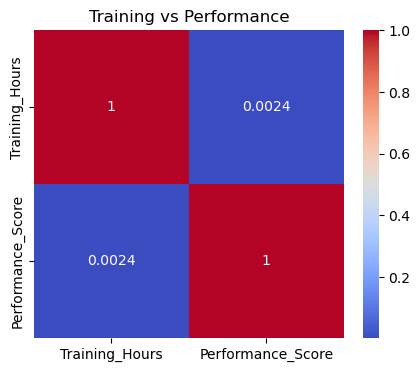

In [25]:
plt.figure(figsize=(5,4))

sns.heatmap(
corr1,
annot=True,
cmap="coolwarm"
)

plt.title(
"Training vs Performance"
)

plt.show()

In [26]:
corr2=df[
[
"Work_Hours_Per_Week",
"Employee_Satisfaction_Score"
]
].corr()

corr2

,Work_Hours_Per_Week,Employee_Satisfaction_Score
Work_Hours_Per_Week,1.00000,0.00053
Employee_Satisfaction_Score,0.00053,1.00000


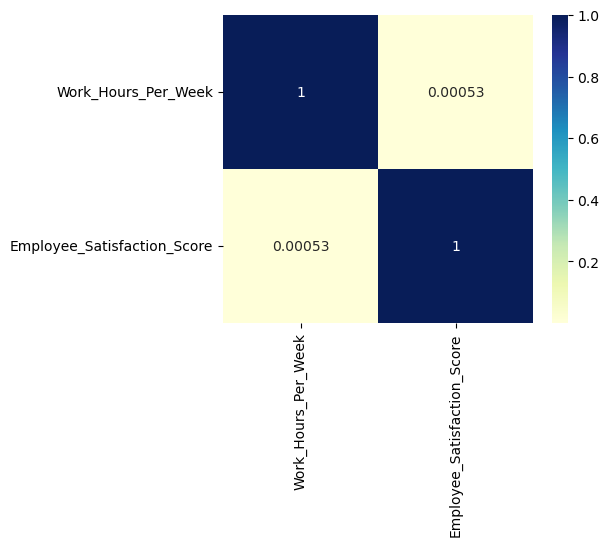

In [27]:
plt.figure(figsize=(5,4))

sns.heatmap(
corr2,
annot=True,
cmap="YlGnBu"
)

plt.show()

In [28]:
corr3=df[
[
"Team_Size",
"Performance_Score"
]
].corr()

corr3

,Team_Size,Performance_Score
Team_Size,1.000000,-0.005174
Performance_Score,-0.005174,1.000000


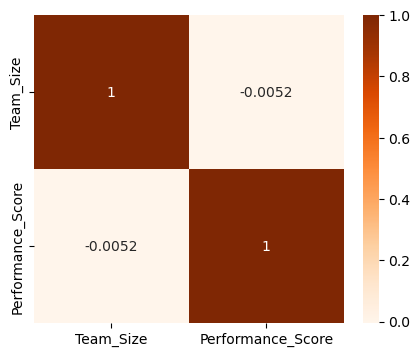

In [29]:
plt.figure(figsize=(5,4))

sns.heatmap(
corr3,
annot=True,
cmap="Oranges"
)

plt.show()

In [30]:
corr4=df[
[
"Monthly_Salary",
"Employee_Satisfaction_Score"
]
].corr()

corr4

,Monthly_Salary,Employee_Satisfaction_Score
Monthly_Salary,1.000000,0.001083
Employee_Satisfaction_Score,0.001083,1.000000


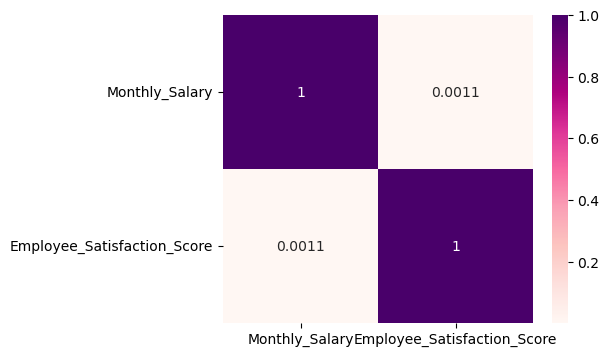

In [31]:
plt.figure(figsize=(5,4))

sns.heatmap(
corr4,
annot=True,
cmap="RdPu"
)

plt.show()

In [32]:
from scipy.stats import ttest_ind

low = df[df["Overtime_Hours"] < 10]["Employee_Satisfaction_Score"]

high = df[df["Overtime_Hours"] >= 10]["Employee_Satisfaction_Score"]

t_stat, p_value = ttest_ind(low, high)

print("T Statistic:", t_stat)
print("P Value:", p_value)

if p_value < 0.05:
    print("Reject H0")
    print("Overtime affects Employee Satisfaction")

else:
    print("Accept H0")
    print("No significant relationship between Overtime and Satisfaction")

T Statistic: 0.8227020043888223
P Value: 0.4106794369907284
Accept H0
No significant relationship between Overtime and Satisfaction


In [33]:
def employee_category(row):

    if (
        row["Performance_Score"] >= 8 and
        row["Employee_Satisfaction_Score"] >= 8
    ):
        return "High Performer"

    elif (
        row["Performance_Score"] >= 5 and
        row["Employee_Satisfaction_Score"] >= 5
    ):
        return "Medium Performer"

    else:
        return "Low Performer"


df["Employee_Category"] = df.apply(
employee_category,
axis=1
)

print(
df["Employee_Category"]
.value_counts()
)

group_analysis = df.groupby(
"Employee_Category"
)[
[
"Monthly_Salary",
"Performance_Score",
"Employee_Satisfaction_Score",
"Training_Hours"
]
].mean()

print(group_analysis)

Employee_Category
Low Performer       99976
Medium Performer       24
Name: count, dtype: int64
                   Monthly_Salary  Performance_Score  \
Employee_Category                                      
Low Performer         6402.865188           2.994949   
Medium Performer      7843.750000           5.000000   

                   Employee_Satisfaction_Score  Training_Hours  
Employee_Category                                               
Low Performer                         2.998608       49.506472  
Medium Performer                      5.000000       47.791667  


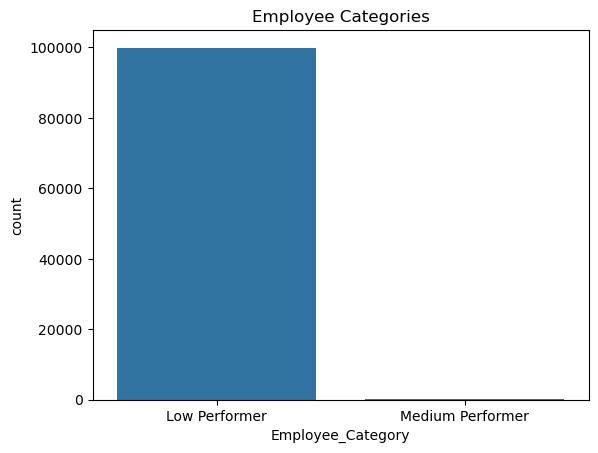

In [34]:
sns.countplot(
x="Employee_Category",
data=df
)

plt.title(
"Employee Categories"
)

plt.show()